In [1]:
# Brug en pæn stil til alle plots
import matplotlib.pyplot as plt
plt.style.use('ggplot')  

# FORELÆSNING 11: Datavisualisering og unsupervised læring

> Exploratory Data Analysis, visualiseringsmetoder, k-means clustering og opdagelse af mønstre uden labels.

### Underviser: Martin Siemienski Andersen mvan@hst.aau.dk

**ST2 - Anvendt Programmering**

# ST2 ANVENDT PROGRAMMERING - Overblik

## Alle forelaesninger



In [ ]:
from IPython.display import HTML
import requests

url = "https://raw.githubusercontent.com/AAU-ST2-Programming/all_lectures/refs/heads/main/overview_files/shared_overview_table11.html"
html = requests.get(url, timeout=30).text
HTML(html)

#,Forelæsning,Mappe,Primære emner
1,Hej C og Python,oop_1,"Programmeringssprog, grundlæggende syntaks, miljøopsætning"
2,"Objekter, indkapsling, interaktion",oop_2,"Klasser, metoder, dataindkapsling, objektinteraktion"
3,Filer og dataindlæsning,oop_3,Fra tekstfil til objekter
4,OOP-integration workshop,oop_4_workshop,"Integration af OOP, fil-I/O, visualisering; overvågningssystemer til enheder"
5,Signalgrundlag,signals_1,"EKG-fysiologi, statistik, peak-detektion"
6,Filtrering og mekaniske signaler,signals_2,"Filtrering, SCG-fysiologi, mekanisk timing, Envelope-udtrækning"
7,"Feature engineering, PPG og regression",signals_3,"Feature-definition, PPG-fysiologi, lineær regression, variationsmål"
8,Signalintegration og etik,signals_4_workshop,"Multimodal integration, refleksion over signal-workflow, etisk analyse"
9,Review af Python Serial Recorder,python_serial_recorder,"Gennemgang af Python Serial Recorder, diskussion af anvendelser og forbedringer"
10,Lineær regression med populationsdata,populations_data_1,"Lineær regression, modelvalidering, residualer"





# K-means clustering i biomedicinsk databehandling

- Hvad k-means er
- Hvordan det beregnes i hånden
- Hvordan man visualiserer og evaluerer klynger
- Hvordan man bruger scikit-learn
- Hvordan man segmenterer et billede
- Hvordan man vurderer performance og fortolker data

## Hvad k-means er

K-means er en algoritme, der opdeler data i k grupper baseret på afstand.

- Hver gruppe repræsenteres af en centroid
- Algoritmen minimerer den samlede afstand mellem datapunkter og deres nærmeste centroid
- Bruges i biomedicinsk ingeniørvidenskab til fx signalanalyse, biomarkører og billeddata, hvor labels ofte mangler

## Hvordan k-means fungerer

Algoritmen gentager to trin:

- **Assignment**: hvert datapunkt tildeles den nærmeste centroid
- **Update**: centroiden flyttes til gennemsnittet af punkterne i sin klynge

Processen fortsætter, indtil centroidernes positioner ikke længere ændrer sig (konvergens).

## Eksempeldata til manuel beregning

Pulsmålinger i bpm:

| Måling | Værdi |
|--------|-------|
| 1      | 95    |
| 2      | 61    |
| 3      | 99    |
| 4      | 63    |
| 5      | 58    |
| 6      | 92    |
| 7      | 67    |
| 8      | 65    |

## Manuel k-means: start

Vi vælger to startcentroider, fx 61 og 95.

1. Beregn afstande fra hvert datapunkt til hver centroid
2. Tildel hvert punkt til den nærmeste centroid

Dette giver den første fordeling i to klynger.

## Manuel k-means: første iteration

Assignment:

- Klynge A: 58, 61, 63, 65, 67
- Klynge B: 92, 95, 99

Update (nye centroider):

- Centroid A = (58 + 61 + 63 + 65 + 67) / 5 = 62.8
- Centroid B = (92 + 95 + 99) / 3 = 95.3

## Manuel k-means: konvergens

Ny assignment med de opdaterede centroider giver samme klynger.

- Ingen ændring i klyngetilhørsforhold
- Algoritmen er konvergeret

Resultat:

- To tydelige klynger
- Centroiderne repræsenterer de to grupper af pulsmålinger

## Manuel k-means: Python implementering,

```python
import numpy as np
def find_kmeans(X,k=2, max_itr=5)
    indices = np.random.choice(len(X), 2, replace=False)
    centroids = X[indices]
    for _ in range(max_itr):
        # Assign points to the nearest centroid
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Update centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(2)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

```

## Visualisering af k-means

Visualisering bruges til at:

- se separationen mellem klynger
- opdage outliers
- vurdere om k er passende
- kommunikere resultater til andre (fx klinikere)

Vi går nu til 2D-eksempler, hvor vi kan se klynger i et scatter-plot.

## Visualisering i 2D

Et 2D scatter-plot kan vise:

- datapunkter farvet efter klynge
- centroids markeret tydeligt
- strukturen i data (fx tre naturlige grupper)

Vi bruger syntetiske 2D-data til at illustrere k-means.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Syntetiske 2D-data
np.random.seed(0)
cluster1 = np.random.normal([2, 2], 0.8, (50, 2))
cluster2 = np.random.normal([6, 6], 0.8, (50, 2))
cluster3 = np.random.normal([2, 6], 0.8, (50, 2))
X = np.vstack([cluster1, cluster2, cluster3])


# Forhåndsberegn iterationer af k-means (uden sklearn, for at kunne vise iterationer)
def kmeans_iterations(X, k=3, max_iter=10):
    centroids = X[np.random.choice(len(X), k, replace=False)]
    history = []
    # Første element: kun centroids, ingen labels endnu
    history.append((centroids.copy(), None))

    for _ in range(max_iter):
        # Assignment
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        history.append((centroids.copy(), labels.copy()))

        # Update
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return history

history = kmeans_iterations(X)

def plot_iteration(i):
    centroids, labels = history[i]
    plt.figure(figsize=(6, 6))
    if labels is None:
        # Første visning: ingen klynger endnu, kun punkter og centroids
        plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
    else:
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis")
    plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X", label='Centroids')
    plt.title(f"K-means iteration {i}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend("lower right")
    plt.show()

interact(plot_iteration, i=IntSlider(min=0, max=len(history)-1, step=1, value=0));

interactive(children=(IntSlider(value=0, description='i', max=4), Output()), _dom_classes=('widget-interact',)…

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">


## Exercise: Martins mystiske pulsmålinger

Scenarie:

Deres elskede chef Martin kommer ind og siger:

"Jeg har otte pulsmålinger, men jeg har mistet labels. Jeg ved kun, at der burde være to grupper. Hjælp mig med at finde dem."

Pulsmålinger (bpm): 95, 61, 99, 63, 58, 92, 67, 65

Opgave:

- Udfør k-means i hånden med k = 2
- Vis hvilke målinger der ender i hver klynge
- Beregn de endelige centroider

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">


## Svar

- Klynge A: 58, 61, 63, 65, 67 → centroid ≈ 62.8
- Klynge B: 92, 95, 99 → centroid ≈ 95.3

## Brug af k-means i scikit-learn

Vi bruger nu scikit-learn til at køre k-means på de syntetiske 2D-data.

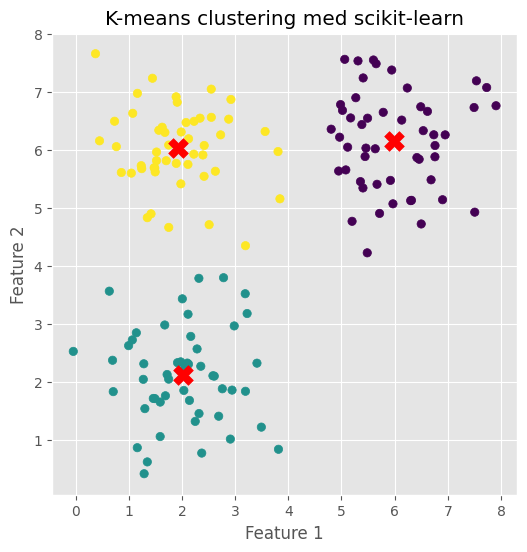

In [4]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3, random_state=0)
labels = model.fit_predict(X)
centroids = model.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis")
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X")
plt.title("K-means clustering med scikit-learn")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Hvordan man vurderer performance

Når k-means er kørt, kan man vurdere kvaliteten af segmenteringen ved at se på:

- hvor kompakte klyngerne er (lav inertia)
- hvor godt de er adskilt (høj silhouette score)
- om centroids ligger meningsfuldt i forhold til data
- om klyngerne giver biologisk eller klinisk mening

Hvis man har "rigtige" labels, kan man også sammenligne med dem (fx accuracy, confusion matrix).



## To centrale mål:

- **Inertia**: summen af kvadrerede afstande fra hvert punkt til dets centroid
- **Silhouette score**: hvor godt et punkt passer i sin klynge sammenlignet med andre klynger

Disse bruges til at vurdere, om segmenteringen er god, og om k er rimeligt valgt.

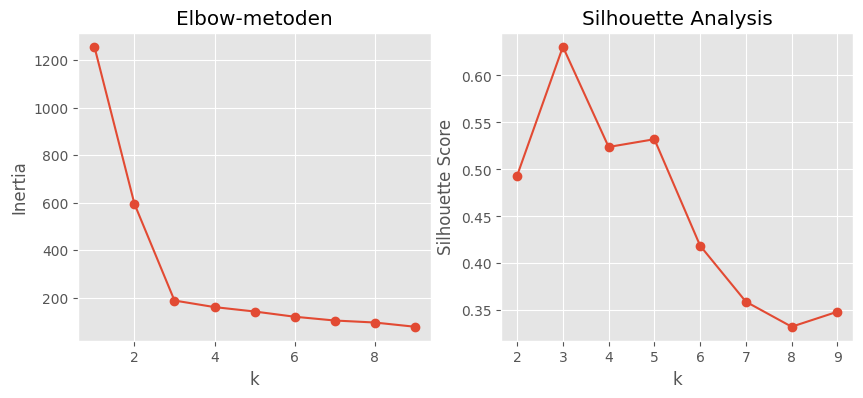

In [5]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
siluettes = []
ks = range(1, 10)
for k in ks:
    model = KMeans(n_clusters=k, random_state=0)
    model.fit(X)
    inertias.append(model.inertia_)
    if k > 1:
        siluettes.append(silhouette_score(X, model.labels_))
    else:
        siluettes.append(float('nan'))  # or None
    model.get_params()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ks, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow-metoden")

plt.subplot(1, 2, 2)
plt.plot(ks, siluettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

## Exercise: Martins glukose-gættekonkurrence

Scenarie:
Din chef Martin er lidt glemsom, og gider ikke gøre alting selv, så han kommer hen og giver dig følgende information, og opgave: "Jeg har ti glukosemålinger, men labels er væk. Jeg tror, der er 2 mønstre. Kan du ikke lige finde ud af det?"

Glukose (mg/dL): 171, 82, 118, 185, 78, 129, 165, 85, 178, 122

Opgave:

- Udfør k-means med 1 til 4 klynger, og vurder hvor mange klynger der er. 
- Argumenter for dit svar.

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">


## Svar

I følge Silhouete analyse er der 3 klynger. i følge Elbow metoden, så er der enten 2 eller 3. 

Når man plotter dataen så lader det til at være 3 klynger, så derfor vil jeg sige at der skal være 3 klynger. 

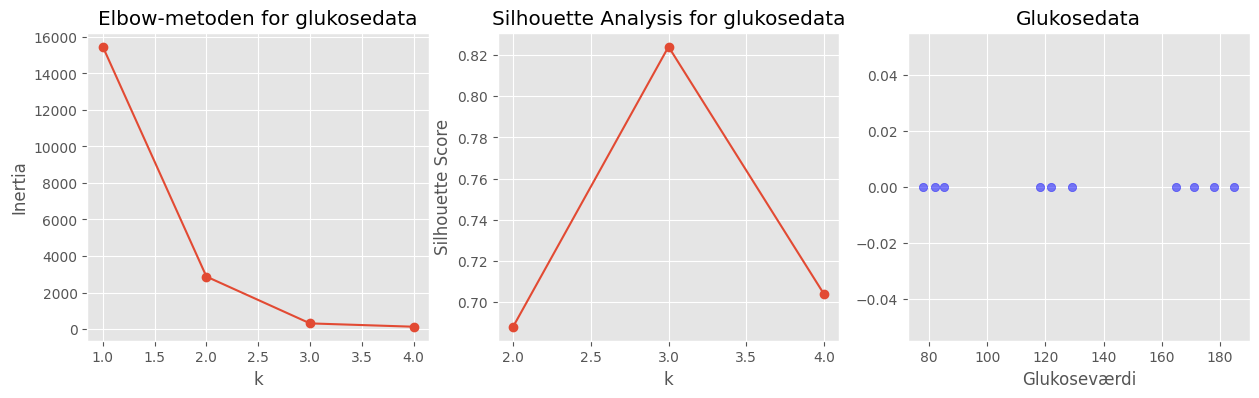

In [6]:
glukose_data = np.array([[171], [82], [118], [185], [78], [129], [165], [85], [178], [122]])
siluettes_glukose = []
innertias_glukose = []
for k in range(1, 5):
    model = KMeans(n_clusters=k, random_state=0)
    model.fit(glukose_data)
    innertias_glukose.append(model.inertia_)
    if k > 1:
        siluettes_glukose.append(silhouette_score(glukose_data, model.labels_))
    else:
        siluettes_glukose.append(float('nan'))  # or None

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(range(1, 5), innertias_glukose, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow-metoden for glukosedata")  
plt.subplot(1, 3, 2)
plt.plot(range(1, 5), siluettes_glukose, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for glukosedata")
plt.subplot(1, 3, 3)
plt.scatter(glukose_data[:, 0], np.zeros_like(glukose_data), c='blue', alpha=0.5)
plt.xlabel("Glukoseværdi")
plt.title("Glukosedata")
plt.show()

## Segmentering af billeder

K-means kan bruges til billedsegmentering ved at gruppere pixelintensiteter.

Workflow:

- Indlæs billedet som NumPy-matrix
- Fladgør billedet til en liste af pixels
- Kør k-means på pixelværdierne
- Form labels tilbage til billedets form
- Visualisér det segmenterede billede

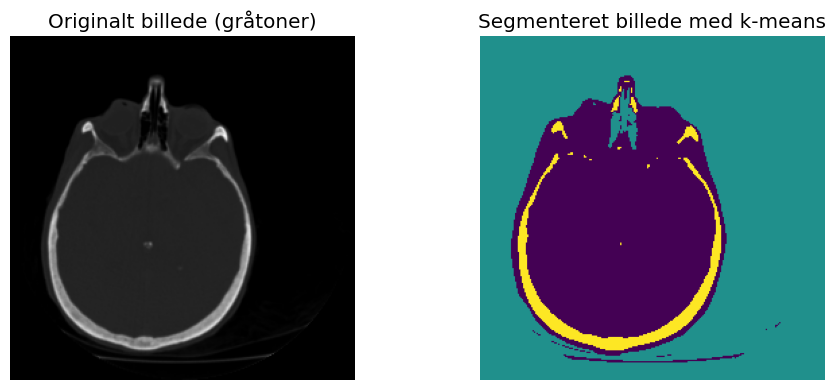

In [7]:
# Segmenter et billede fra URL med k-means, kun med skimage og sklearn
# Husk at installerer pooch, skimage og sklearn, hvis du ikke allerede har det:
from skimage import data
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
images_brain = data.brain()
image = images_brain[6,:,:]

# Fladgør billedet til en liste af pixels
pixels = image.reshape(-1, 1)

# Kør k-means på pixelværdierne
model_img = KMeans(n_clusters=3, random_state=0)
labels_img = model_img.fit_predict(pixels)

# Form labels tilbage til billedets form
segmented = labels_img.reshape(image.shape)

# Visualisér det originale og det segmenterede billede
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Originalt billede (gråtoner)")
plt.axis("off")

plt.subplot(1, 2, 2)
# plot segmented with a colormap that shows the different clusters clearly
plt.imshow(segmented, cmap="viridis")
plt.title("Segmenteret billede med k-means")
plt.axis("off")

plt.tight_layout()
plt.show()

# Scaling: Hvorfor skalere data?

- Mange machine learning-algoritmer (fx k-means, PCA, SVM, regression) er følsomme over for størrelsesforholdet mellem features.
- Features med store værdier kan dominere afstandsberegninger og modeltræning.
- Eksempel: Højde (i cm) og vægt (i kg) – vægten kan få større indflydelse, hvis den har større numerisk skala.
- Uskalerede data kan føre til dårlige eller misvisende resultater.




# Scaling: Hvornår er skalering vigtig?

- Når algoritmen bruger afstande (fx k-means, k-NN, PCA).
- Når features har forskellige enheder eller størrelsesordener.
- Skalering er ofte ikke nødvendig for træer (fx decision trees, random forest).
- Typiske metoder: MinMax-skalering (0-1), Standardisering (mean=0, std=1).
- God praksis: Skalér altid, hvis du er i tvivl!


# Scaling: Skalering med højde og BMI

Forestil dig et datasæt med to features:
- Højde i centimeter (fx 150–200)
- BMI (Body Mass Index, fx 18–35)

Hvis du bruger k-means clustering uden skalering, vil højden (fordi den har større numeriske værdier) dominere afstandsberegningen. Det betyder, at klyngerne primært opdeles efter højde, og BMI får næsten ingen betydning.

Hvis du derimod standardiserer begge features (så de har samme gennemsnit og standardafvigelse), får både højde og BMI lige stor indflydelse på klyngedannelsen. Det giver et mere retvisende resultat, hvor begge variable bidrager til analysen.

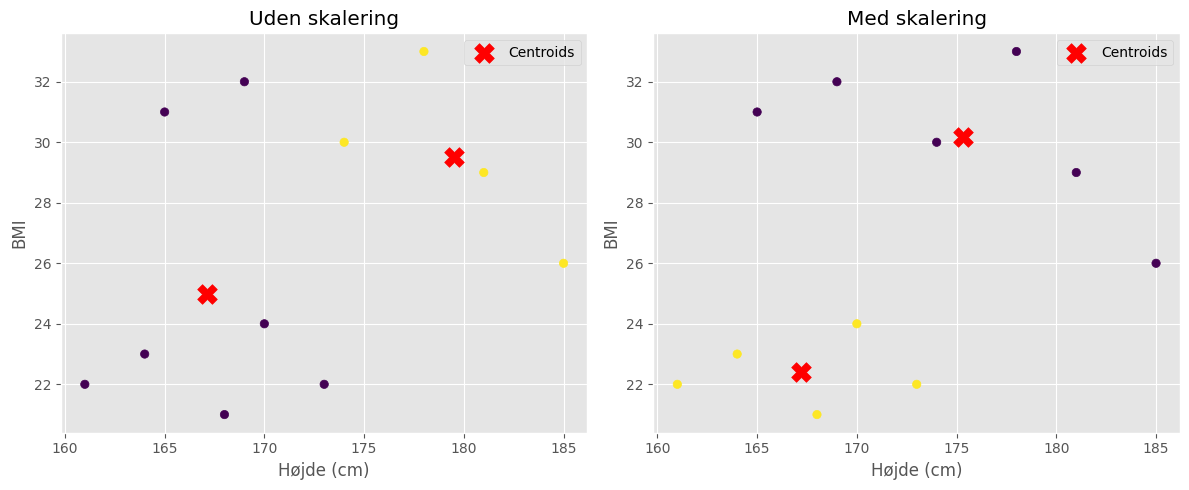

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Manually chosen heights (cm) and BMI (two groups)
X = np.array([
    [161, 22],
    [164, 23],
    [168, 21],
    [170, 24],
    [173, 22],
    [165, 31],
    [169, 32],
    [174, 30],
    [178, 33],
    [181, 29],
    [185, 26]
])

# K-means without scaling
model1 = KMeans(n_clusters=2, random_state=0)
labels1 = model1.fit_predict(X)
centroids1 = model1.cluster_centers_

# K-means with scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model2 = KMeans(n_clusters=2, random_state=0)
labels2 = model2.fit_predict(X_scaled)
centroids2 = scaler.inverse_transform(model2.cluster_centers_)  # transform back to original scale

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(X[:, 0], X[:, 1], c=labels1)
axs[0].scatter(centroids1[:, 0], centroids1[:, 1], c="red", s=200, marker="X", label="Centroids")
axs[0].set_title("Uden skalering")
axs[0].set_xlabel("Højde (cm)")
axs[0].set_ylabel("BMI")
axs[0].legend()

axs[1].scatter(X[:, 0], X[:, 1], c=labels2)
axs[1].scatter(centroids2[:, 0], centroids2[:, 1], c="red", s=200, marker="X", label="Centroids")
axs[1].set_title("Med skalering")
axs[1].set_xlabel("Højde (cm)")
axs[1].set_ylabel("BMI")
axs[1].legend()

plt.tight_layout()
plt.show()

## Hvad man kan sige om data efter clustering

Efter clustering kan man fx beskrive:

- hvor mange naturlige grupper der opstår
- hvilke mønstre der findes i data
- hvilke features der adskiller grupperne
- om der er outliers eller meget små klynger
- om data ser symmetrisk, spredt, kompakt eller multimodal ud

I biomedicinsk kontekst kan man fx sige:

- om der er forskellige fysiologiske tilstande
- om der er patientgrupper med forskellige risikoprofiler
- om et billede kan opdeles i meningsfulde vævssegmenter

## Afslutning

Efter denne gennemgang kan I:

- forstå k-means og dets grundidé
- beregne k-means i hånden på simple 1D-data
- visualisere og evaluere klynger i 2D
- bruge scikit-learn til k-means clustering
- segmentere et billede med k-means
- vurdere performance og sige noget kvalificeret om data efter clustering

# Opgaver




# **Exercise: “Martin’s ECG Beat Bonanza”**  


### Scenario  
Your awesome boss Martin has extracted **two NumPy arrays** from thousands of ECG beats:  
- `peak_amplitude`  
- `beat_width`  
He says:  
“These two features should help us group similar heartbeats. Use your new k‑means skills in Python to see if patterns appear.”

### What they know after the lecture  
- How to use NumPy arrays as input to scikit‑learn.  
- How to scale features using NumPy operations.  
- How to run `KMeans` and visualize results.

### Task  
Use NumPy to combine the two feature arrays into a 2D dataset, scale it, run k‑means with different values of *k*, and visualize the clusters. Martin wants you to interpret what each cluster might represent (e.g., normal beats, premature beats, noisy beats).





# **Exercise: “Martin’s MRI Tissue Treasure Hunt”**  

### Scenario  
Your awesome boss Martin hands you a **grayscale MRI slice** stored as a NumPy array. He says:  
“I bet the pixel intensities fall into a few natural tissue types. Use k‑means to uncover them.”

### What they know after the lecture  
- How to reshape NumPy arrays.  
- How to apply k‑means to imaging data.  
- How to reconstruct cluster labels back into an image‑shaped array.

### Task  
Reshape the MRI array into a list of pixel intensities, cluster them into *k = 3* groups using k‑means, and reshape the labels back into an image. Martin wants you to explain what each cluster might correspond to (e.g., CSF, gray matter, white matter).





# **Exercise: “Martin’s Metabolic Mystery Patients”**  


### Scenario  
Your awesome boss Martin gives you three NumPy arrays representing anonymized patient biomarkers:  
- `fasting_glucose`  
- `hdl_cholesterol`  
- `triglycerides`  
He says:  
“I think there are hidden metabolic subgroups here. Use k‑means to explore them.”

### What they know after the lecture  
- How to preprocess multi‑dimensional data using NumPy.  
- How to run k‑means with scikit‑learn.  
- How to evaluate cluster quality.

### Task  
Combine the three biomarker arrays into a 2D NumPy dataset, cluster the patients into 2–5 groups, compare the results using inertia or silhouette score, and interpret the clusters in a biomedical context. Martin wants to know whether the clusters might reflect metabolic health patterns.

